# 02 - Baseline Classification (Decision Tree)
Notebook này huấn luyện mô hình Decision Tree làm thuật toán cơ sở để so sánh với Random Forest và XGBoost.


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

SEED = 42
# Load từ data/processed (dữ liệu đã được xử lý trong notebook 01)
EVENTS_PATH = '../data/processed/events_cleaned.csv'
MODEL_OUTPUT_PATH = '../models/decision_tree_baseline.pkl'
METRICS_OUTPUT_PATH = '../models/decision_tree_baseline_metrics.json'

# Create output directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

In [2]:
events_df = pd.read_csv(EVENTS_PATH)
events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])

print('Da tai du lieu thanh cong!')
print(f'So dong: {len(events_df):,}')
events_df.head()

Da tai du lieu thanh cong!
So dong: 4,259,061


,timestamp,visitorid,event,itemid,transactionid,categoryid,available,parentid
0,2015-06-02 05:02:12.117,257597,view,355908,0,1173.0,1.0,805.0
1,2015-06-02 05:02:12.117,257597,view,355908,0,1173.0,0.0,805.0
2,2015-06-02 05:50:14.164,992329,view,248676,0,1231.0,1.0,901.0
3,2015-06-02 05:13:19.827,111016,view,318965,0,NaN,NaN,NaN
4,2015-06-02 05:12:35.914,483717,view,253185,0,914.0,0.0,226.0


## Trích xuất đặc trưng theo visitor
- event_*: số lần thực hiện từng hành vi
- total_events, unique_items_viewed, unique_categories_viewed
- session_duration_seconds, most_frequent_hour
- Nhãn `converted`: 1 nếu visitor có transaction, ngược lại là 0

In [3]:
event_features = events_df.pivot_table(
    index='visitorid',
    columns='event',
    aggfunc='size',
    fill_value=0
)
event_features.columns = ['event_' + c for c in event_features.columns]

visitor_agg_features = events_df.groupby('visitorid').agg(
    total_events=('event', 'count'),
    unique_items_viewed=('itemid', 'nunique'),
    unique_categories_viewed=('categoryid', 'nunique')
)

time_features = events_df.groupby('visitorid')['timestamp'].agg(['min', 'max'])
time_features['session_duration_seconds'] = (time_features['max'] - time_features['min']).dt.total_seconds()

events_df['hour_of_day'] = events_df['timestamp'].dt.hour
hour_features = events_df.groupby('visitorid')['hour_of_day'].agg(
    most_frequent_hour=lambda x: x.mode()[0]
)

features_df = (
    event_features
    .join(visitor_agg_features)
    .join(time_features[['session_duration_seconds']])
    .join(hour_features)
    .fillna(0)
)

if 'event_transaction' not in features_df.columns:
    features_df['event_transaction'] = 0

features_df['converted'] = (features_df['event_transaction'] > 0).astype(int)

print(f'Tong so visitor: {features_df.shape[0]:,}')
print(f"Ti le converted: {features_df['converted'].mean():.2%}")
features_df.head()

Tong so visitor: 1,407,580
Ti le converted: 0.83%


,event_addtocart,event_transaction,event_view,total_events,unique_items_viewed,unique_categories_viewed,session_duration_seconds,most_frequent_hour,converted
visitorid,,,,,,,,,
0,0,0,5,5,3,3,327.736,20,0
1,0,0,1,1,1,1,0.000,17,0
2,0,0,12,12,4,2,1753.278,17,0
3,0,0,1,1,1,1,0.000,7,0
4,0,0,1,1,1,0,0.000,21,0


In [4]:
y = features_df['converted']
X = features_df.drop(columns=['converted', 'event_transaction'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'Ti le converted train: {y_train.mean():.2%}')
print(f'Ti le converted test: {y_test.mean():.2%}')

X_train: (1126064, 7)
X_test: (281516, 7)
Ti le converted train: 0.83%
Ti le converted test: 0.83%


## Huấn luyện Decision Tree Baseline
Cấu hình `class_weight='balanced'` để giảm ảnh hưởng mất cân bằng lớp.

In [5]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=SEED
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

metrics = {
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred, zero_division=0)),
    'recall': float(recall_score(y_test, y_pred, zero_division=0)),
    'f1': float(f1_score(y_test, y_pred, zero_division=0)),
    'roc_auc': float(roc_auc_score(y_test, y_proba))
}

print('Decision Tree Baseline Metrics:')
for k, v in metrics.items():
    print(f'- {k}: {v:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

Decision Tree Baseline Metrics:
- accuracy: 0.9875
- precision: 0.3968
- recall: 0.9612
- f1: 0.5617
- roc_auc: 0.9934

Classification report:
              precision    recall  f1-score   support

           0     0.9997    0.9877    0.9937    279172
           1     0.3968    0.9612    0.5617      2344

    accuracy                         0.9875    281516
   macro avg     0.6982    0.9745    0.7777    281516
weighted avg     0.9947    0.9875    0.9901    281516



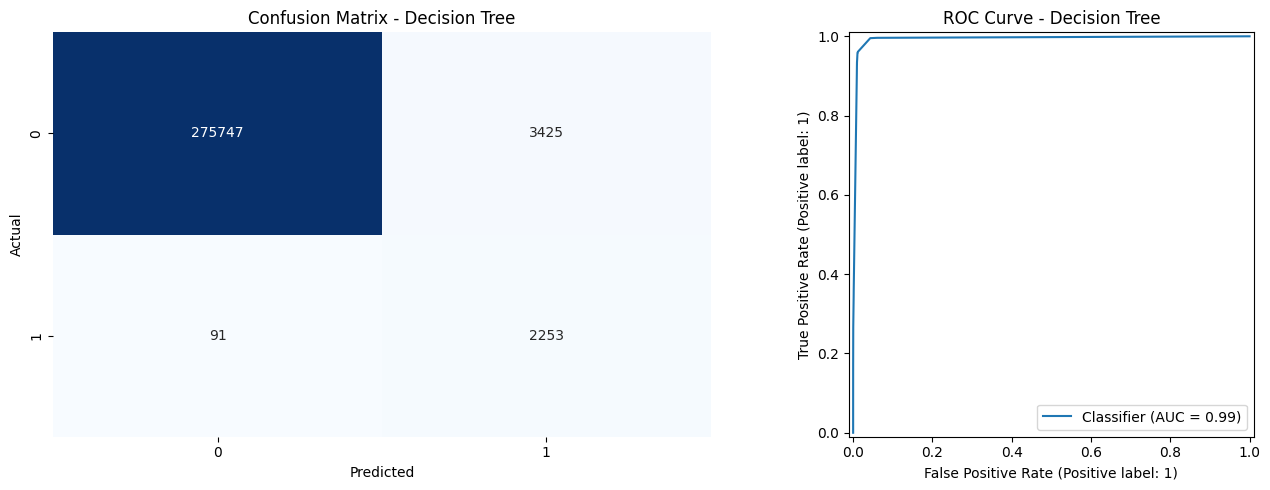

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve - Decision Tree')

plt.tight_layout()
plt.show()

In [7]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 15 feature importance:')
display(importance_df.head(15))

Top 15 feature importance:


,feature,importance
0,event_addtocart,0.831808
1,event_view,0.084842
2,total_events,0.071376
5,session_duration_seconds,0.011102
3,unique_items_viewed,0.000722
4,unique_categories_viewed,0.000093
6,most_frequent_hour,0.000056


In [8]:
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(dt_model, MODEL_OUTPUT_PATH)

with open(METRICS_OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print(f'Da luu model tai: {MODEL_OUTPUT_PATH}')
print(f'Da luu metrics tai: {METRICS_OUTPUT_PATH}')

Da luu model tai: ../models/decision_tree_baseline.pkl
Da luu metrics tai: ../models/decision_tree_baseline_metrics.json


Saved predictions to: ../outputs/predictions_output.csv


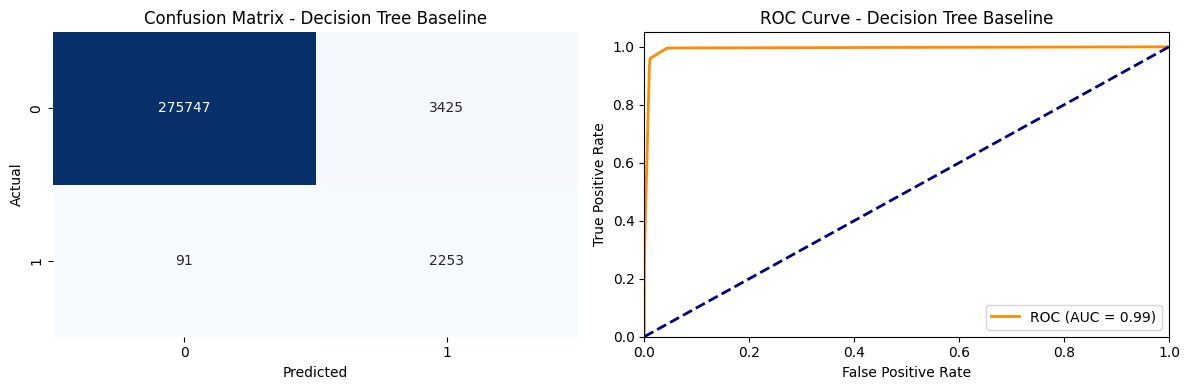

Saved visualization to: ../report/figures/evaluation_confusion_matrix.png


In [9]:
# Lưu Predictions và Visualizations
os.makedirs('../report/figures', exist_ok=True)

# Lưu predictions
predictions_df = pd.DataFrame({
    'label (converted)': y_test,
    'predict (converted)': y_pred,
    'predict_probability (converted)': y_proba
})
predictions_df.to_csv('../outputs/predictions_output.csv', index=False)
print(f'Saved predictions to: ../outputs/predictions_output.csv')

# Vẽ Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Decision Tree Baseline')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Decision Tree Baseline')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('../report/figures/evaluation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved visualization to: ../report/figures/evaluation_confusion_matrix.png')